# CheXNet -> MURA Domain Transfer
## Phase 1 - Environment & Workspace Calibration

Run these cells top-to-bottom at the start of **every** Colab session.
The T4 VM is wiped on disconnect, so Cell 2 re-fetches the repo each time.

Before running: **Runtime -> Change runtime type -> T4 GPU**.

In [9]:
# Cell 1 - Confirm the runtime has the T4 GPU
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
Tesla T4, 15360 MiB


In [10]:
# Cell 2 - Bootstrap: pull the whole project onto the Colab VM
# Identical for both collaborators. No Google Drive needed - git carries
# the code, the 81 MB weights, and the MURA data.
import os

REPO_URL = "https://github.com/sofiaorlov9821/CheXNet.git"
CHEXNET  = "/content/CheXNet"

if not os.path.exists(CHEXNET):
    !git clone {REPO_URL} {CHEXNET}      # first run of the session
else:
    !cd {CHEXNET} && git pull            # already cloned -> just update

assert os.path.exists(f"{CHEXNET}/model.pth.tar"), "clone failed - check repo access"
print("[OK] Project ready at", CHEXNET)
print(os.listdir(CHEXNET))

Cloning into '/content/CheXNet'...
remote: Enumerating objects: 4235, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 4235 (delta 42), reused 47 (delta 39), pack-reused 4177 (from 1)
Receiving objects: 100% (4235/4235), 275.71 MiB | 26.78 MiB/s, done.
Resolving deltas: 100% (43/43), done.
Updating files: 100% (2140/2140), done.
[OK] Project ready at /content/CheXNet
['.gitattributes', 'model.py', 'ChestX-ray14', '.git', 'final_p.ipynb', 'read_data.py', '.gitignore', 'localization', 'MURA_MSK_Xrays_files', 'model.pth.tar', 'README.md']


In [11]:
# Cell 3 - Make CheXNet importable and load the model class
import sys
if CHEXNET not in sys.path:
    sys.path.append(CHEXNET)             # append = won't shadow torch

from model import DenseNet121            # gets the class; does NOT run main()
MURA_DIR = f"{CHEXNET}/MURA_MSK_Xrays_files"
assert os.path.isdir(MURA_DIR), "MURA folder not found"
print("[OK] Imported DenseNet121")
print("[OK] MURA data at", MURA_DIR)

[OK] Imported DenseNet121
[OK] MURA data at /content/CheXNet/MURA_MSK_Xrays_files


In [12]:
# Cell 4 - Confirm the GPU is live (final Phase 1 check)
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE")
assert DEVICE.type == "cuda", "No GPU - Runtime > Change runtime type > T4 GPU"

Device: cuda
GPU: Tesla T4


---
## Phase 2 - Preprocessing & MURA Subset Loading

Body part: **XR_FOREARM** (the subset in this repo).  
Labels come from the study-folder name: `..._positive` -> **1 (abnormal)**, `..._negative` -> **0 (normal)**.

Pipeline: `SquarePad` (no distortion) -> `Resize(224)` -> spatial augmentations (train only) -> ImageNet normalization.

In [13]:
# Cell 5 - Imports + SquarePad + transforms
import os
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


class SquarePad:
    """Pad a PIL image to a square (side = longer edge) BEFORE resizing.

    Resizing a non-square X-ray straight to 224x224 stretches the anatomy.
    Padding to a square first preserves the aspect ratio so bones keep their
    true proportions. Padding is symmetric and filled with 0 (black), which
    matches the typical dark radiograph background.
    """
    def __call__(self, image):
        w, h = image.size
        s = max(w, h)
        left = (s - w) // 2
        top  = (s - h) // 2
        right = s - w - left
        bottom = s - h - top
        return TF.pad(image, (left, top, right, bottom), fill=0)


# Train: augment for spatial invariance. Eval: deterministic, no augmentation.
train_tf = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
print('[OK] SquarePad + transforms defined')

[OK] SquarePad + transforms defined


In [14]:
# Cell 6 - MURA Dataset
class MURADataset(Dataset):
    """MURA musculoskeletal radiographs as a binary image classifier dataset.

    Directory layout:
        <root>/<split>/<body_part>/patientXXXXX/studyN_positive|negative/imageN.png

    The label is parsed from the study-folder name ('positive' -> 1 abnormal,
    'negative' -> 0 normal). Each PNG is treated as one independent sample
    (per-image classification), which is standard for a proof-of-concept.

    Args:
        root:      path to MURA_MSK_Xrays_files
        body_part: e.g. 'XR_FOREARM'
        split:     'train' or 'valid'
        transform: torchvision transform applied to each PIL image
    """
    def __init__(self, root, body_part='XR_FOREARM', split='train', transform=None):
        self.transform = transform
        self.samples = []  # (image_path, label)
        base = os.path.join(root, split, body_part)
        for patient in sorted(os.listdir(base)):
            pdir = os.path.join(base, patient)
            if not os.path.isdir(pdir):
                continue
            for study in sorted(os.listdir(pdir)):
                sdir = os.path.join(pdir, study)
                if not os.path.isdir(sdir):
                    continue
                label = 1 if 'positive' in study.lower() else 0
                for fname in sorted(os.listdir(sdir)):
                    if fname.lower().endswith('.png'):   # skip .DS_Store etc.
                        self.samples.append((os.path.join(sdir, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')   # 1-ch X-ray -> 3-ch for DenseNet
        if self.transform is not None:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)
print('[OK] MURADataset defined')

[OK] MURADataset defined


In [15]:
# Cell 7 - Build datasets, dataloaders, and report class balance
BATCH_SIZE = 32   # comfortable on a T4 at 224x224
BODY_PART  = 'XR_FOREARM'

train_ds = MURADataset(MURA_DIR, BODY_PART, 'train', train_tf)
valid_ds = MURADataset(MURA_DIR, BODY_PART, 'valid', eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# Class balance (MURA is imbalanced - we'll use this for pos_weight later)
def counts(ds):
    pos = sum(l for _, l in ds.samples)
    return len(ds), int(pos), len(ds) - int(pos)

n_tr, pos_tr, neg_tr = counts(train_ds)
n_va, pos_va, neg_va = counts(valid_ds)
print(f'TRAIN: {n_tr} imgs | abnormal {pos_tr} / normal {neg_tr}')
print(f'VALID: {n_va} imgs | abnormal {pos_va} / normal {neg_va}')
pos_weight = torch.tensor([neg_tr / max(pos_tr, 1)])   # save for Phase 3 loss
print(f'pos_weight (neg/pos) = {pos_weight.item():.3f}')

TRAIN: 1825 imgs | abnormal 661 / normal 1164
VALID: 301 imgs | abnormal 151 / normal 150
pos_weight (neg/pos) = 1.761


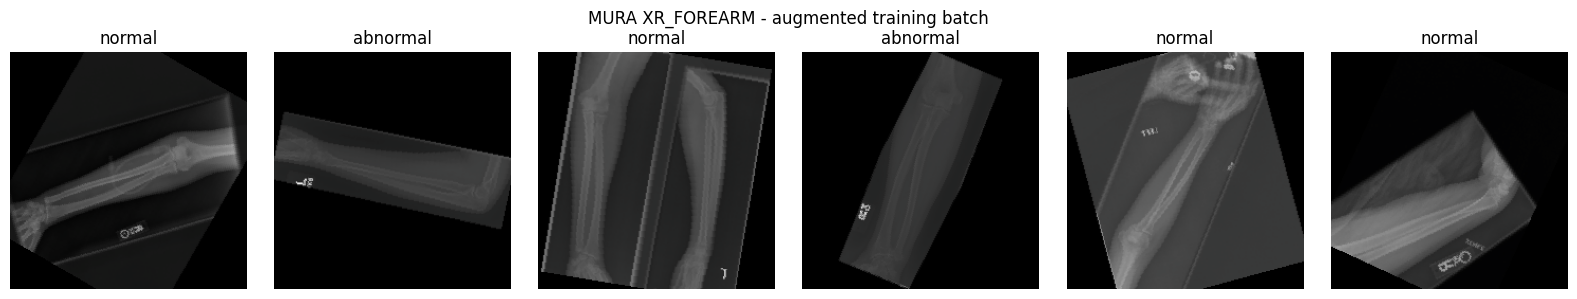

Batch tensor: torch.Size([32, 3, 224, 224])


In [16]:
# Cell 8 - Sanity check: visualise one augmented batch
import matplotlib.pyplot as plt
import numpy as np

mean = np.array(IMAGENET_MEAN); std = np.array(IMAGENET_STD)
imgs, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for i, ax in enumerate(axes):
    img = imgs[i].permute(1, 2, 0).numpy() * std + mean   # un-normalize
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title('abnormal' if labels[i] == 1 else 'normal')
    ax.axis('off')
plt.suptitle('MURA XR_FOREARM - augmented training batch')
plt.tight_layout(); plt.show()
print('Batch tensor:', imgs.shape)   # expect [32, 3, 224, 224]